# Seminar 06: BatchNorm, Augmentation, and Residual Ideas on CIFAR-10

**Student Version**

Goals for today:
- Implement the core idea of **BatchNorm2d** yourself
- Add production BatchNorm layers to a CIFAR-10 CNN
- Inspect image augmentation visually instead of treating it as magic
- Understand the residual connection shape constraint
- Compare baseline, BatchNorm, and augmentation experiments like a researcher


## 0. Setup


In [1]:
import math
import random
import time
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cuda')

### Albumentations import
Albumentations is used only in the augmentation section. Earlier BatchNorm and residual tasks work without it.


In [2]:
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    ALBUMENTATIONS_AVAILABLE = True
except ImportError:
    A = None
    ToTensorV2 = None
    ALBUMENTATIONS_AVAILABLE = False
    print('Albumentations is not installed. Install it before Exercise 3, for example: pip install albumentations')

ALBUMENTATIONS_AVAILABLE


True

### Configuration


In [3]:
@dataclass
class Config:
    seed: int = 42
    train_n: object = 12000
    val_n: int = 2000
    batch_size: int = 128
    epochs: int = 8
    lr: float = 1e-3


cfg = Config()
cfg


Config(seed=42, train_n=12000, val_n=2000, batch_size=128, epochs=8, lr=0.001)

### Helpers


In [4]:
CIFAR10_CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)


def denormalize_cifar(x):
    mean = torch.tensor(CIFAR10_MEAN).view(1, 3, 1, 1)
    std = torch.tensor(CIFAR10_STD).view(1, 3, 1, 1)
    return (x.detach().cpu() * std + mean).clamp(0, 1)


def show_images(images, labels=None, class_names=None, nrow=8, figsize=(12, 4), denormalize=False):
    images = images.detach().cpu()
    if denormalize:
        images = denormalize_cifar(images)
    n_images = images.shape[0]
    ncol = int(math.ceil(n_images / nrow))
    plt.figure(figsize=figsize)
    for i in range(n_images):
        plt.subplot(ncol, nrow, i + 1)
        plt.imshow(images[i].permute(1, 2, 0).numpy())
        plt.axis('off')
        if labels is not None:
            label = int(labels[i])
            title = class_names[label] if class_names is not None else str(label)
            plt.title(title, fontsize=8)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def accuracy_multiclass(logits, y_true):
    preds = logits.argmax(dim=1)
    return (preds == y_true).float().mean().item()


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_history():
    return {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}


def plot_history(history, title_prefix=''):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure()
    plt.plot(epochs, history['train_loss'], label='train')
    plt.plot(epochs, history['val_loss'], label='val')
    plt.title(f'{title_prefix}Loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history['train_acc'], label='train')
    plt.plot(epochs, history['val_acc'], label='val')
    plt.title(f'{title_prefix}Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend()
    plt.show()


def summarize_result(name, model, history, elapsed_sec):
    return {
        'name': name,
        'params': count_parameters(model),
        'best_val_acc': float(max(history['val_acc'])),
        'final_train_acc': float(history['train_acc'][-1]),
        'final_val_acc': float(history['val_acc'][-1]),
        'final_gap': float(history['train_acc'][-1] - history['val_acc'][-1]),
        'elapsed_sec': float(elapsed_sec),
    }


## 1. Provided CIFAR-10 Setup

CIFAR-10 loading is infrastructure today. Notice the important change from FashionMNIST: images are RGB and shaped `[B, 3, 32, 32]`.


100%|██████████| 170M/170M [00:05<00:00, 28.5MB/s]


xb: torch.Size([128, 3, 32, 32]) torch.float32
yb: torch.Size([128]) torch.int64


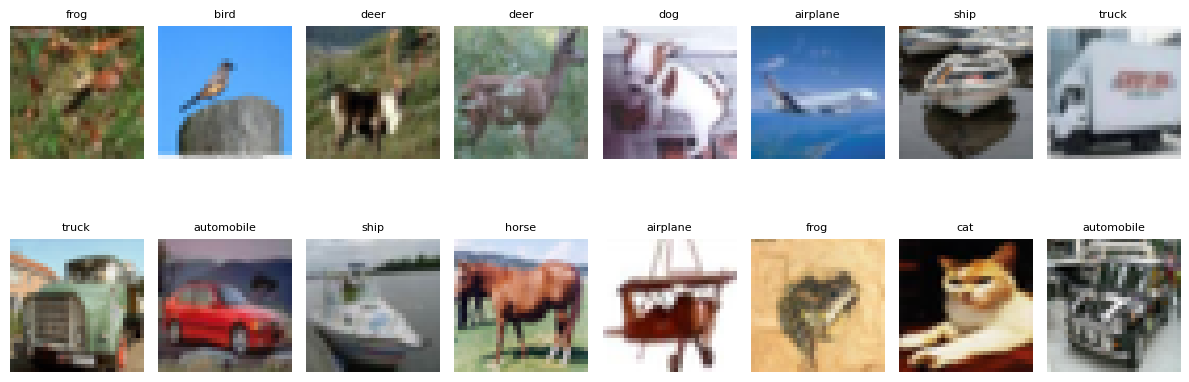

In [5]:
def build_cifar10_loaders(cfg):
    basic_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    ])
    train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)

    generator = torch.Generator().manual_seed(cfg.seed)
    perm = torch.randperm(len(train_full), generator=generator)
    val_idx = perm[:cfg.val_n]
    train_idx = perm[cfg.val_n:]
    if cfg.train_n is not None:
        train_idx = train_idx[:cfg.train_n]

    train_ds = Subset(train_full, train_idx.tolist())
    val_ds = Subset(train_full, val_idx.tolist())
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader, train_idx, val_idx


train_loader, val_loader, train_idx, val_idx = build_cifar10_loaders(cfg)
xb, yb = next(iter(train_loader))
print('xb:', xb.shape, xb.dtype)
print('yb:', yb.shape, yb.dtype)
show_images(xb[:16], labels=yb[:16], class_names=CIFAR10_CLASS_NAMES, nrow=8, figsize=(12, 5), denormalize=True)

assert xb.ndim == 4 and xb.shape[1:] == (3, 32, 32)
assert yb.ndim == 1 and yb.dtype in (torch.int64, torch.long)
assert len(set(train_idx.tolist()).intersection(set(val_idx.tolist()))) == 0


### Provided Training Helpers and Baseline CNN
Training code is provided so we can spend seminar time on BatchNorm, augmentation, residuals, and experiment interpretation.


In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits.detach(), yb) * bs
        total_n += bs
    return total_loss / total_n, total_acc / total_n


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    total_n = 0
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)
        bs = xb.shape[0]
        total_loss += loss.item() * bs
        total_acc += accuracy_multiclass(logits, yb) * bs
        total_n += bs
    return total_loss / total_n, total_acc / total_n


def run_training(name, model, train_loader, val_loader, cfg):
    seed_everything(cfg.seed)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    loss_fn = nn.CrossEntropyLoss()
    history = make_history()
    started = time.time()

    for epoch in range(1, cfg.epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, opt, loss_fn)
        va_loss, va_acc = evaluate(model, val_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        print(f'{name:15s} epoch {epoch:02d} | train {tr_loss:.4f}/{tr_acc:.3f} | val {va_loss:.4f}/{va_acc:.3f}')

    elapsed_sec = time.time() - started
    return {'name': name, 'model': model, 'history': history, 'elapsed_sec': elapsed_sec}


## 2. Exercise 1: Implement BatchNorm2d

Implement a compact version of BatchNorm for 4D CNN activations.

For input shaped `[B, C, H, W]`, BatchNorm2d computes one mean and variance per channel, using all batch and spatial positions.

Formula:
```text
x_hat = (x - mean) / sqrt(var + eps)
y = gamma * x_hat + beta
```

Contract:
- `num_features` is the number of channels `C`
- in `train()` mode, use current batch statistics and update `running_mean` / `running_var`
- in `eval()` mode, use stored running statistics
- `weight` is gamma, initialized to ones
- `bias` is beta, initialized to zeros

Useful hints:
- channel statistics use dimensions `(0, 2, 3)`
- `mean[None, :, None, None]` changes shape `[C] -> [1, C, 1, 1]`, so PyTorch can subtract one value from each channel across the whole batch/image
- use `unbiased=False` for variance to match PyTorch BatchNorm behavior more closely


In [7]:
# Exercise 1

class ManualBatchNorm2d(nn.Module):
    def __init__(self, num_features, eps=1e-5, momentum=0.1):
        super().__init__()
        self.num_features = num_features
        self.eps = eps
        self.momentum = momentum
        self.weight = nn.Parameter(torch.ones(num_features))
        self.bias = nn.Parameter(torch.zeros(num_features))
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))

    def forward(self, x):
        if self.training:
            batch_mean = x.mean(dim=(0,2,3))
            batch_var = x.var(dim=(0,2,3), unbiased=False)

            # Update running statistics without tracking gradients.
            # Easier-to-read version of the running average formula:
            # new_running = old_running * (1 - momentum) + batch_stat * momentum

            self.running_mean = self.running_mean * (1 - self.momentum) + batch_mean * self.momentum
            self.running_var = self.running_var * (1 - self.momentum) + batch_var * self.momentum

            mean = batch_mean
            var = batch_var
        else:
            mean = self.running_mean
            var = self.running_var

        # Add empty dimensions so [C] becomes [1, C, 1, 1] and broadcasts over [B, C, H, W].
        mean = mean[None, :, None, None]
        var = var[None, :, None, None]
        weight = self.weight[None, :, None, None]
        bias = self.bias[None, :, None, None]

        x_hat = (x - mean) / torch.sqrt(var - self.eps)
        y = weight * x_hat + bias
        return y


manual_bn = ManualBatchNorm2d(num_features=3)
manual_bn.train()
channel_shift = torch.tensor([10.0, -3.0, 2.0])[None, :, None, None]
x_bn = torch.randn(12, 3, 4, 4) * 5 + channel_shift
y_bn = manual_bn(x_bn)

channel_mean = y_bn.mean(dim=(0, 2, 3))
channel_var = y_bn.var(dim=(0, 2, 3), unbiased=False)
print('mean after BN:', channel_mean)
print('var after BN :', channel_var)
print('running mean:', manual_bn.running_mean)
print('running var :', manual_bn.running_var)

assert y_bn.shape == x_bn.shape
assert torch.allclose(channel_mean, torch.zeros(3), atol=1e-5)
assert torch.allclose(channel_var, torch.ones(3), atol=1e-4)
assert not torch.allclose(manual_bn.running_mean, torch.zeros(3))
assert not torch.allclose(manual_bn.running_var, torch.ones(3))

manual_bn.eval()
y_eval_1 = manual_bn(x_bn)
y_eval_2 = manual_bn(x_bn)
assert torch.allclose(y_eval_1, y_eval_2)


mean after BN: tensor([-1.0928e-07,  7.4506e-09, -3.5817e-08], grad_fn=<MeanBackward1>)
var after BN : tensor([1.0000, 1.0000, 1.0000], grad_fn=<VarBackward0>)
running mean: tensor([ 0.9865, -0.2810,  0.2245])
running var : tensor([3.2177, 3.1362, 3.1065])


## 3. Exercise 2: Add BatchNorm to the CNN

Now use PyTorch's production BatchNorm layer inside the CNN.

Upgrade each block from:
```text
Conv -> ReLU -> Pool
```
to:
```text
Conv -> BatchNorm -> ReLU -> Pool
```

Basic contract:
```python
nn.BatchNorm2d(num_features)
```
`num_features` must match the number of channels produced by the preceding convolution.

Fill `CNNWithBN`. Infer the BatchNorm sizes from the convolution outputs.


In [8]:
# Exercise 2

class CNNWithBN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


bn_probe_model = CNNWithBN().to(device)
with torch.no_grad():
    logits = bn_probe_model(xb[:8].to(device))

bn_layers = [module for module in bn_probe_model.modules() if isinstance(module, nn.BatchNorm2d)]
print('logits shape:', logits.shape)
print('BatchNorm feature counts:', [layer.num_features for layer in bn_layers])
print('parameters:', count_parameters(bn_probe_model))

assert logits.shape == (8, 10)
assert [layer.num_features for layer in bn_layers] == [32, 64]
assert count_parameters(bn_probe_model) > count_parameters(BaselineCNN())


logits shape: torch.Size([8, 10])
BatchNorm feature counts: [32, 64]
parameters: 545290


## 4. Baseline vs BatchNorm

Run the baseline CNN and the BatchNorm CNN on the same split. Watch both the curves and the train-validation gap.


baseline        epoch 01 | train 1.8062/0.349 | val 1.4635/0.458
baseline        epoch 02 | train 1.3630/0.512 | val 1.2807/0.533
baseline        epoch 03 | train 1.2020/0.571 | val 1.1993/0.566
baseline        epoch 04 | train 1.0671/0.625 | val 1.1490/0.579
baseline        epoch 05 | train 0.9647/0.659 | val 1.0777/0.626
baseline        epoch 06 | train 0.8776/0.695 | val 1.1215/0.607
baseline        epoch 07 | train 0.7941/0.723 | val 1.0721/0.628
baseline        epoch 08 | train 0.7110/0.753 | val 1.0595/0.642


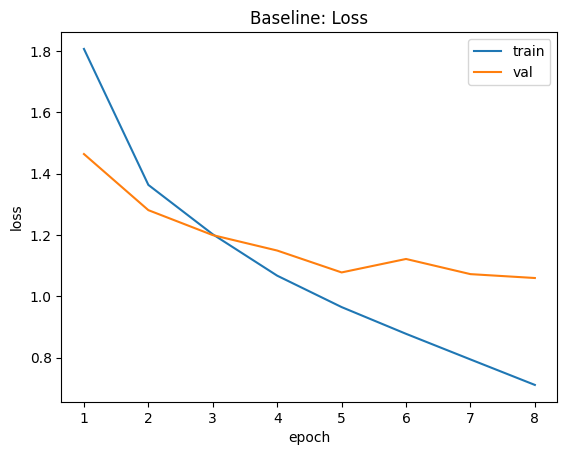

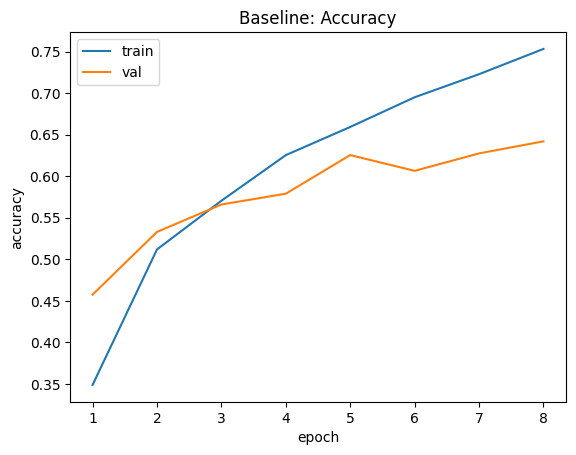

batchnorm       epoch 01 | train 1.7662/0.362 | val 1.3704/0.510
batchnorm       epoch 02 | train 1.2878/0.541 | val 1.2179/0.567
batchnorm       epoch 03 | train 1.1239/0.597 | val 1.1056/0.603
batchnorm       epoch 04 | train 0.9905/0.651 | val 1.0820/0.624
batchnorm       epoch 05 | train 0.9033/0.683 | val 1.0316/0.639
batchnorm       epoch 06 | train 0.8576/0.701 | val 1.0010/0.655
batchnorm       epoch 07 | train 0.7695/0.733 | val 1.0409/0.648
batchnorm       epoch 08 | train 0.7216/0.749 | val 1.0257/0.653


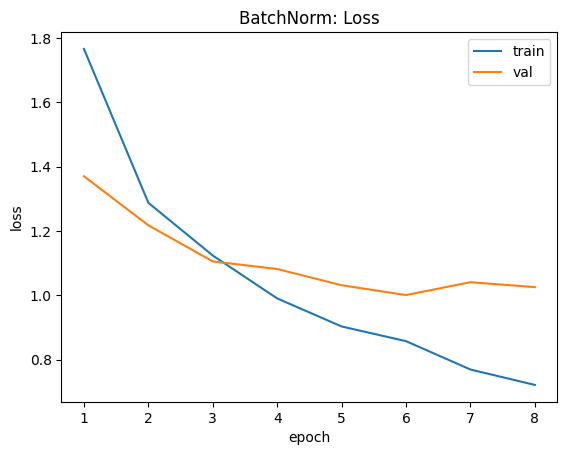

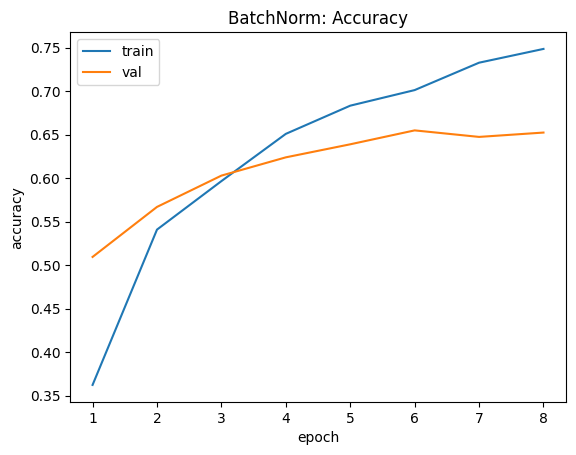

,name,params,best_val_acc,final_train_acc,final_val_acc,final_gap,elapsed_sec
0,baseline,545098,0.642,0.753250,0.6420,0.111250,30.277146
1,batchnorm,545290,0.655,0.748667,0.6525,0.096167,30.194877


In [9]:
baseline_result = run_training('baseline', BaselineCNN(), train_loader, val_loader, cfg)
plot_history(baseline_result['history'], title_prefix='Baseline: ')
baseline_summary = summarize_result('baseline', baseline_result['model'], baseline_result['history'], baseline_result['elapsed_sec'])

bn_result = run_training('batchnorm', CNNWithBN(), train_loader, val_loader, cfg)
plot_history(bn_result['history'], title_prefix='BatchNorm: ')
bn_summary = summarize_result('batchnorm', bn_result['model'], bn_result['history'], bn_result['elapsed_sec'])

pd.DataFrame([baseline_summary, bn_summary])


## 5. Exercise 3: Augmentation Visual Lab

Create training and validation augmentation pipelines, then apply the training pipeline several times to the same image.

Training pipeline should include these Albumentations classes:
- `A.HorizontalFlip(p=0.5)`
- `A.PadIfNeeded(min_height=40, min_width=40, border_mode=0, fill=0)`
- `A.RandomCrop(height=32, width=32)`
- `A.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)`
- `ToTensorV2()`

Validation pipeline should include only:
- `A.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD)`
- `ToTensorV2()`

Useful Albumentations contracts:
```python
A.Compose([...])
augmented = aug(image=np.array(pil_image))['image']
ToTensorV2()  # converts image to a PyTorch tensor shaped [C, H, W]
```


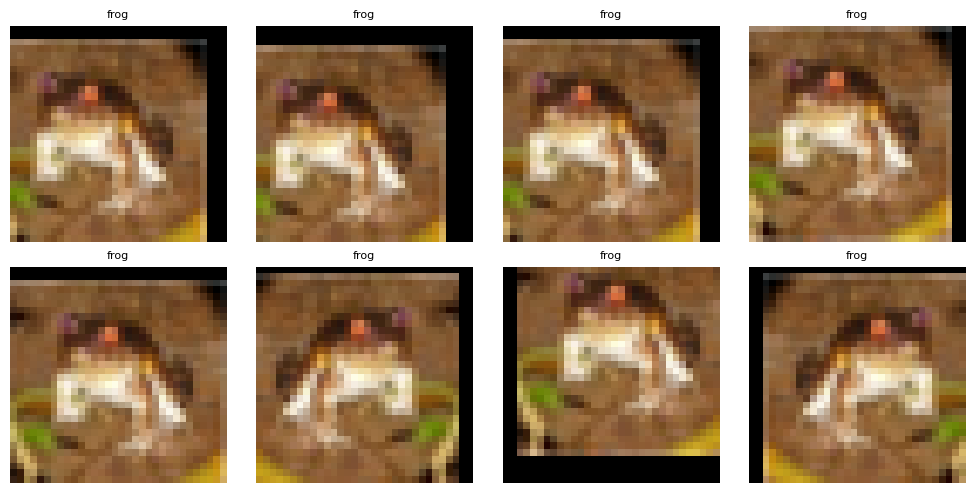

In [14]:
# Exercise 3

assert ALBUMENTATIONS_AVAILABLE, 'Install albumentations before this exercise.'

train_aug = A.Compose([
  A.HorizontalFlip(p=0.5),
  A.PadIfNeeded(min_height=40, min_width=40, border_mode=0, fill=0),
  A.RandomCrop(height=32, width=32),
  A.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
  ToTensorV2()
])
val_aug = A.Compose([
    A.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
    ToTensorV2()
])

raw_train_for_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
raw_image, raw_label = raw_train_for_aug[0]
raw_np = np.array(raw_image)

augmented_versions = [train_aug(image=raw_np)['image'] for _ in range(8)]
augmented_batch = torch.stack(augmented_versions)
val_version_1 = val_aug(image=raw_np)["image"]
val_version_2 = val_aug(image=raw_np)["image"]

# Show several augmented versions of the same raw image.

show_images(augmented_batch, labels=[raw_label] * augmented_batch.shape[0], class_names=CIFAR10_CLASS_NAMES,
            nrow=4, figsize=(10, 5), denormalize=True)

assert augmented_batch.shape[1:] == (3, 32, 32)
assert val_version_1.shape == (3, 32, 32)
assert torch.allclose(val_version_1, val_version_2)
assert not all(torch.allclose(augmented_batch[0], augmented_batch[i]) for i in range(1, augmented_batch.shape[0]))


## 6. Train with BatchNorm + Augmentation

The dataset wrapper and training run are provided. The important question is how augmentation changes the curves and the final gap.


xb_aug: torch.Size([128, 3, 32, 32]) torch.float32


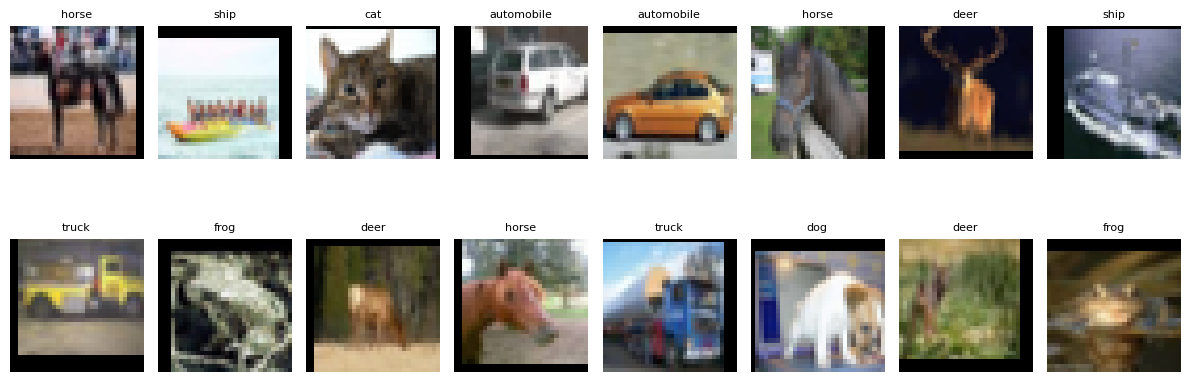

bn_aug          epoch 01 | train 1.8411/0.337 | val 1.4871/0.444
bn_aug          epoch 02 | train 1.5094/0.440 | val 1.3773/0.497
bn_aug          epoch 03 | train 1.4065/0.483 | val 1.2679/0.545
bn_aug          epoch 04 | train 1.3116/0.523 | val 1.1686/0.588
bn_aug          epoch 05 | train 1.2492/0.553 | val 1.2071/0.566
bn_aug          epoch 06 | train 1.2129/0.567 | val 1.0569/0.623
bn_aug          epoch 07 | train 1.1450/0.589 | val 1.0459/0.632
bn_aug          epoch 08 | train 1.1204/0.597 | val 1.0202/0.647


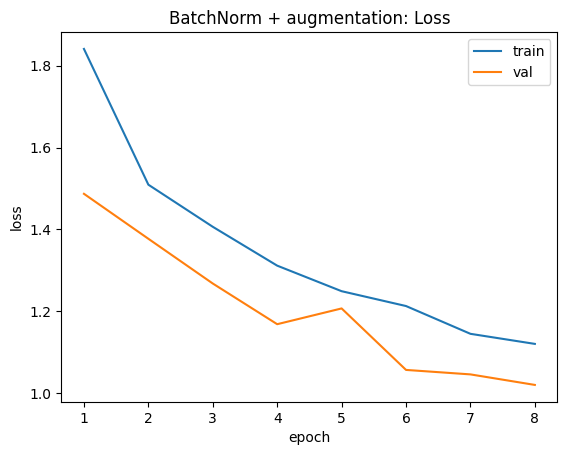

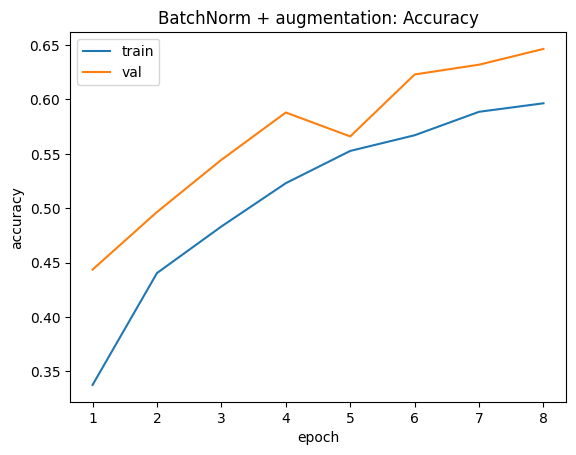

In [15]:
class AlbumentationsCIFAR10(Dataset):
    def __init__(self, base_dataset, aug):
        self.base_dataset = base_dataset
        self.aug = aug

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        image = np.array(image)
        image = self.aug(image=image)['image']
        return image, label


raw_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
raw_train_subset = Subset(raw_train, train_idx.tolist())
raw_val_subset = Subset(raw_train, val_idx.tolist())

aug_train_ds = AlbumentationsCIFAR10(raw_train_subset, train_aug)
aug_val_ds = AlbumentationsCIFAR10(raw_val_subset, val_aug)
aug_train_loader = DataLoader(aug_train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=2, pin_memory=True)
aug_val_loader = DataLoader(aug_val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

xb_aug, yb_aug = next(iter(aug_train_loader))
print('xb_aug:', xb_aug.shape, xb_aug.dtype)
show_images(xb_aug[:16], labels=yb_aug[:16], class_names=CIFAR10_CLASS_NAMES, nrow=8, figsize=(12, 5), denormalize=True)

bn_aug_result = run_training('bn_aug', CNNWithBN(), aug_train_loader, aug_val_loader, cfg)
plot_history(bn_aug_result['history'], title_prefix='BatchNorm + augmentation: ')
bn_aug_summary = summarize_result('bn_aug', bn_aug_result['model'], bn_aug_result['history'], bn_aug_result['elapsed_sec'])


## 7. Exercise 4: Residual Block Shape and Identity Lab

Implement a small residual block for tensors with the same number of input and output channels.

Block structure:
```text
x -> Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> add x -> ReLU
```

Contract:
- input and output shapes must match
- no pooling or stride inside the block
- the skip connection is valid only because channel count and spatial size stay unchanged

Useful check idea: if both convolution weights are zero, the block should behave like `ReLU(x)` because only the skip path remains.


In [16]:
# Exercise 4

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + x
        out = self.relu(out)
        return out


res_block = ResidualBlock(channels=16)
x_res = torch.randn(4, 16, 12, 12)
y_res = res_block(x_res)

zero_block = ResidualBlock(channels=16)
for module in zero_block.modules():
    if isinstance(module, nn.Conv2d):
        nn.init.zeros_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
zero_block.train()
y_zero = zero_block(x_res)

assert y_res.shape == x_res.shape
assert torch.allclose(y_zero, torch.relu(x_res), atol=1e-5)


## 8. Exercise 5: Compare Experiments

Use the three completed runs:
- baseline CNN
- CNN + BatchNorm
- CNN + BatchNorm + augmentation

Create a comparison table and answer the experimental question: which model would you keep?

Fill:
- `comparison_df`
- `best_run_name`
- `largest_gap_run_name`
- `augmentation_reduced_gap`
- `chosen_run_reason`

Useful hint: the train-validation gap is `final_train_acc - final_val_acc`. A larger gap often means more overfitting.


In [17]:
# Exercise 5

experiment_summaries = [baseline_summary, bn_summary, bn_aug_summary]

comparison_df = pd.DataFrame(experiment_summaries).sort_values('best_val_acc', ascending=False).reset_index(drop=True)
best_run_name = comparison_df.iloc[0]['name']
largest_gap_run_name = comparison_df.sort_values('final_gap', ascending=False).iloc[0]['name']
augmentation_reduced_gap = bool(bn_aug_summary['final_gap'] < bn_summary['final_gap'])
chosen_run_reason = (
    f"I would keep {best_run_name}: it has the best validation accuracy in this run. "
    "I would also check the train-validation gap before trusting it blindly."
)

assert isinstance(comparison_df, pd.DataFrame)
assert set(['name', 'params', 'best_val_acc', 'final_train_acc', 'final_val_acc', 'final_gap']).issubset(comparison_df.columns)
assert len(comparison_df) == 3
assert best_run_name in set(comparison_df['name'])
assert largest_gap_run_name in set(comparison_df['name'])
assert isinstance(augmentation_reduced_gap, bool)
assert isinstance(chosen_run_reason, str) and len(chosen_run_reason) > 20

comparison_df


,name,params,best_val_acc,final_train_acc,final_val_acc,final_gap,elapsed_sec
0,batchnorm,545290,0.6550,0.748667,0.6525,0.096167,30.194877
1,bn_aug,545290,0.6465,0.596500,0.6465,-0.050000,28.631562
2,baseline,545098,0.6420,0.753250,0.6420,0.111250,30.277146


## 9. Wrap-up Questions
1. In your manual BatchNorm, which dimensions are averaged over and why?
2. Why does BatchNorm need different behavior in `train()` and `eval()`?
3. Where did we place BatchNorm in the CNN block?
4. Why should augmentation be stochastic for training but clean/deterministic for validation?
5. Did augmentation reduce the train-validation gap in this run?
6. Why must a simple residual block keep input and output shapes equal?
7. Which run would you keep, and what would you try next?
